In [ ]:
# BiocManager::install("ggtree")

In [ ]:
library(ape)
library(aplot)
library(ggtree)
library(cowplot)
library(tidyverse)
library(data.table)

In [70]:
# read the guide tree
guide_tree <- read.tree('../data/phylogeny_49_species.nwk')

In [71]:
# df with length and type of each conting in each reference genome
ref_len_df <- fread('../data/contigs_in_ref_genomes.tsv')

In [73]:
# information about the sex of individuals used to assemble the reference genome
ref_sex <- fread('../data/ref49_sex.txt') 


In [74]:
# a plot with reference sex

ref_sex_plot <- ref_sex %>%

        ggplot(aes(reference, 0, label = sex, fill = sex, color = sex)) + 
            scale_y_discrete(expand = c(0, 0))+
            geom_label()+
            scale_color_manual(values = c('black', 'white', 'white', 'white'))+
            scale_fill_manual(values = c('white', '#1e81b0', '#1e81b0', '#1e81b0'))+
            ggtitle('sex')+
            coord_flip() + 
            theme_tree2() +
            theme(legend.text = element_text(size = 14),
                  legend.position="none",
                  axis.text.x = element_text(size = 12), 
                  plot.title = element_text(size = 16), 
                  axis.title.x = element_text(size = 14))

In [75]:
# plots with contig length and annotation for autosomes and chrX

ref_len_plots <- lapply(c('autosomes', 'chrX'), function(chrom){
    
    tmp <- ref_len_df %>%
        filter(chr == chrom) %>%
        arrange(reference, desc(below_1mb), ref_len) %>%
        group_by(reference) %>%
        mutate(ref_chrom = paste0(reference, 1e5 + seq_along(chr))) %>%
        ungroup() %>%
        distinct(ref_chrom) 

    max_len <- ref_len_df %>%
        filter(chr == chrom) %>%
        group_by(reference) %>%
        summarise(ref_len = sum(ref_len)) %>%
        filter(ref_len == max(ref_len))
    
    scaling_f <- max_len$ref_len / 1e8
        
    p <- ref_len_df %>%
    filter(chr == chrom) %>%
        arrange(reference, desc(below_1mb), ref_len) %>%
        group_by(reference) %>%
        mutate(ref_chrom = paste0(reference, 1e5 + seq_along(chr))) %>%
    mutate(ref_chrom = factor(ref_chrom, tmp$ref_chrom))  %>%
    mutate(annotation = ifelse(is.na(annotation), 'other', annotation)) %>%
    mutate(annotation = factor(annotation, levels = c('chrX', 'chrY', 'other'))) %>%
    arrange(ref_chrom) %>%
    
        ggplot(aes(reference, ref_len/1e6, color = ref_chrom, alpha = below_1mb, fill = annotation)) + 
            # geom_rect(aes(xmin = 42.5, xmax = 49.5, ymin = -Inf, ymax = Inf), fill = 'lightblue1', alpha = 0.2, linewidth = 0)+
            geom_col(linewidth = 0.1) +  
            scale_fill_manual(values = c('chrY' = '#1e81b0', 'chrX' = 'darkorange', 'other' = 'grey90')) +
            scale_color_manual(values = rep('black', 1e4), guide = "none")+
            scale_alpha_manual(values = c(1, 0))+
            scale_y_continuous(expand = c(0, scaling_f))+
            coord_flip() + 
            theme_tree2() +
            ylab('length, Mb')+
            ggtitle(chrom)+
            theme(axis.text.x = element_text(size = 12), 
                  plot.title = element_text(size = 16), 
                  axis.title.x = element_text(size = 14), 
                     legend.position="none")

    return(p)
})

In [76]:
# dirty-dirty
# make a mock df with a 0-long contig annotated as chrX to add to the chrY df below. This is to have all chromosomes annotations in the legend

ref_len_df_mock <- ref_len_df %>%
filter(grepl('Homo', reference)) %>%
ungroup() %>%
filter(row_number()==1) %>%
mutate(ref_len = 0) %>%
mutate(annotation = 'chrX')

In [77]:
# the same plot as for autosomes and chrX above, just with the legend

chrom <- 'chrY'

    tmp <- ref_len_df %>%
        filter(chr == chrom) %>%
        arrange(reference, desc(below_1mb), ref_len) %>%
        group_by(reference) %>%
        mutate(ref_chrom = paste0(reference, 1e5 + seq_along(chr))) %>%
        ungroup() %>%
        distinct(ref_chrom) 

    max_len <- ref_len_df %>%
        filter(chr == chrom) %>%
        group_by(reference) %>%
        summarise(ref_len = sum(ref_len)) %>%
        filter(ref_len == max(ref_len))
    
    scaling_f <- max_len$ref_len / 1e8
        
    pY <- ref_len_df %>%

    filter(chr == chrom) %>%
    rbind(., ref_len_df_mock) %>%
        arrange(reference, desc(below_1mb), ref_len) %>%
        group_by(reference) %>%
        mutate(ref_chrom = paste0(reference, 1e5 + seq_along(chr))) %>%
    mutate(ref_chrom = factor(ref_chrom, tmp$ref_chrom))  %>%
    arrange(ref_chrom) %>%
    mutate(annotation = ifelse(is.na(annotation), 'other', annotation)) %>%
    mutate(annotation = factor(annotation, levels = c('chrX', 'chrY', 'other'))) %>%
    # ungroup() %>%

        ggplot(aes(reference, ref_len/1e6, color = ref_chrom, alpha = below_1mb, fill = annotation)) + 
            # geom_rect(aes(xmin = 42.5, xmax = 49.5, ymin = -Inf, ymax = Inf), fill = 'lightblue1', alpha = 0.1, linewidth = 0)+
            geom_col(linewidth = 0.1) +  
            scale_fill_manual(values = c('chrY' = '#1e81b0', 'chrX' = 'darkorange', 'other' = 'grey90'), drop = FALSE) +
            scale_color_manual(values = rep('black', 1e4), guide = "none")+
            scale_alpha_manual(values = c(1, 0), guide = "none")+
            scale_y_continuous(expand = c(0, scaling_f))+
            coord_flip() + 
            theme_tree2() +
            ylab('length, Mb')+
            ggtitle(chrom)+
            theme(legend.text = element_text(size = 14),
                  # legend.title =  element_text(size = 16),
                  legend.title =  element_blank(),
                  axis.text.x = element_text(size = 12), 
                  plot.title = element_text(size = 16), 
                  axis.title.x = element_text(size = 14))

In [78]:
# adding chrY to the list of plots
ref_len_plots[[3]] <- pY

In [79]:

guide_tree_clado <- compute.brlen(guide_tree, method = "cladogram")


tree <- ggtree(guide_tree_clado) +
    geom_tiplab(size=5, align=TRUE, linesize=.5) + 
    xlim_tree(6)+
    theme_tree2() +
    theme(axis.text.x = element_blank(),
          axis.ticks.x=element_blank(),
          axis.line=element_blank(),
         legend.position="none")

tree <- flip(tree, 55, 70) %>% flip(23, 77)

In [80]:
figure <- ref_len_plots[[1]] %>% insert_left(tree, width = 1.1) %>% insert_right(ref_len_plots[[2]], width = 0.5) %>% insert_right(ref_sex_plot, width = 0.15) %>% insert_right(ref_len_plots[[3]], width = 0.5) 

Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_label()`).”


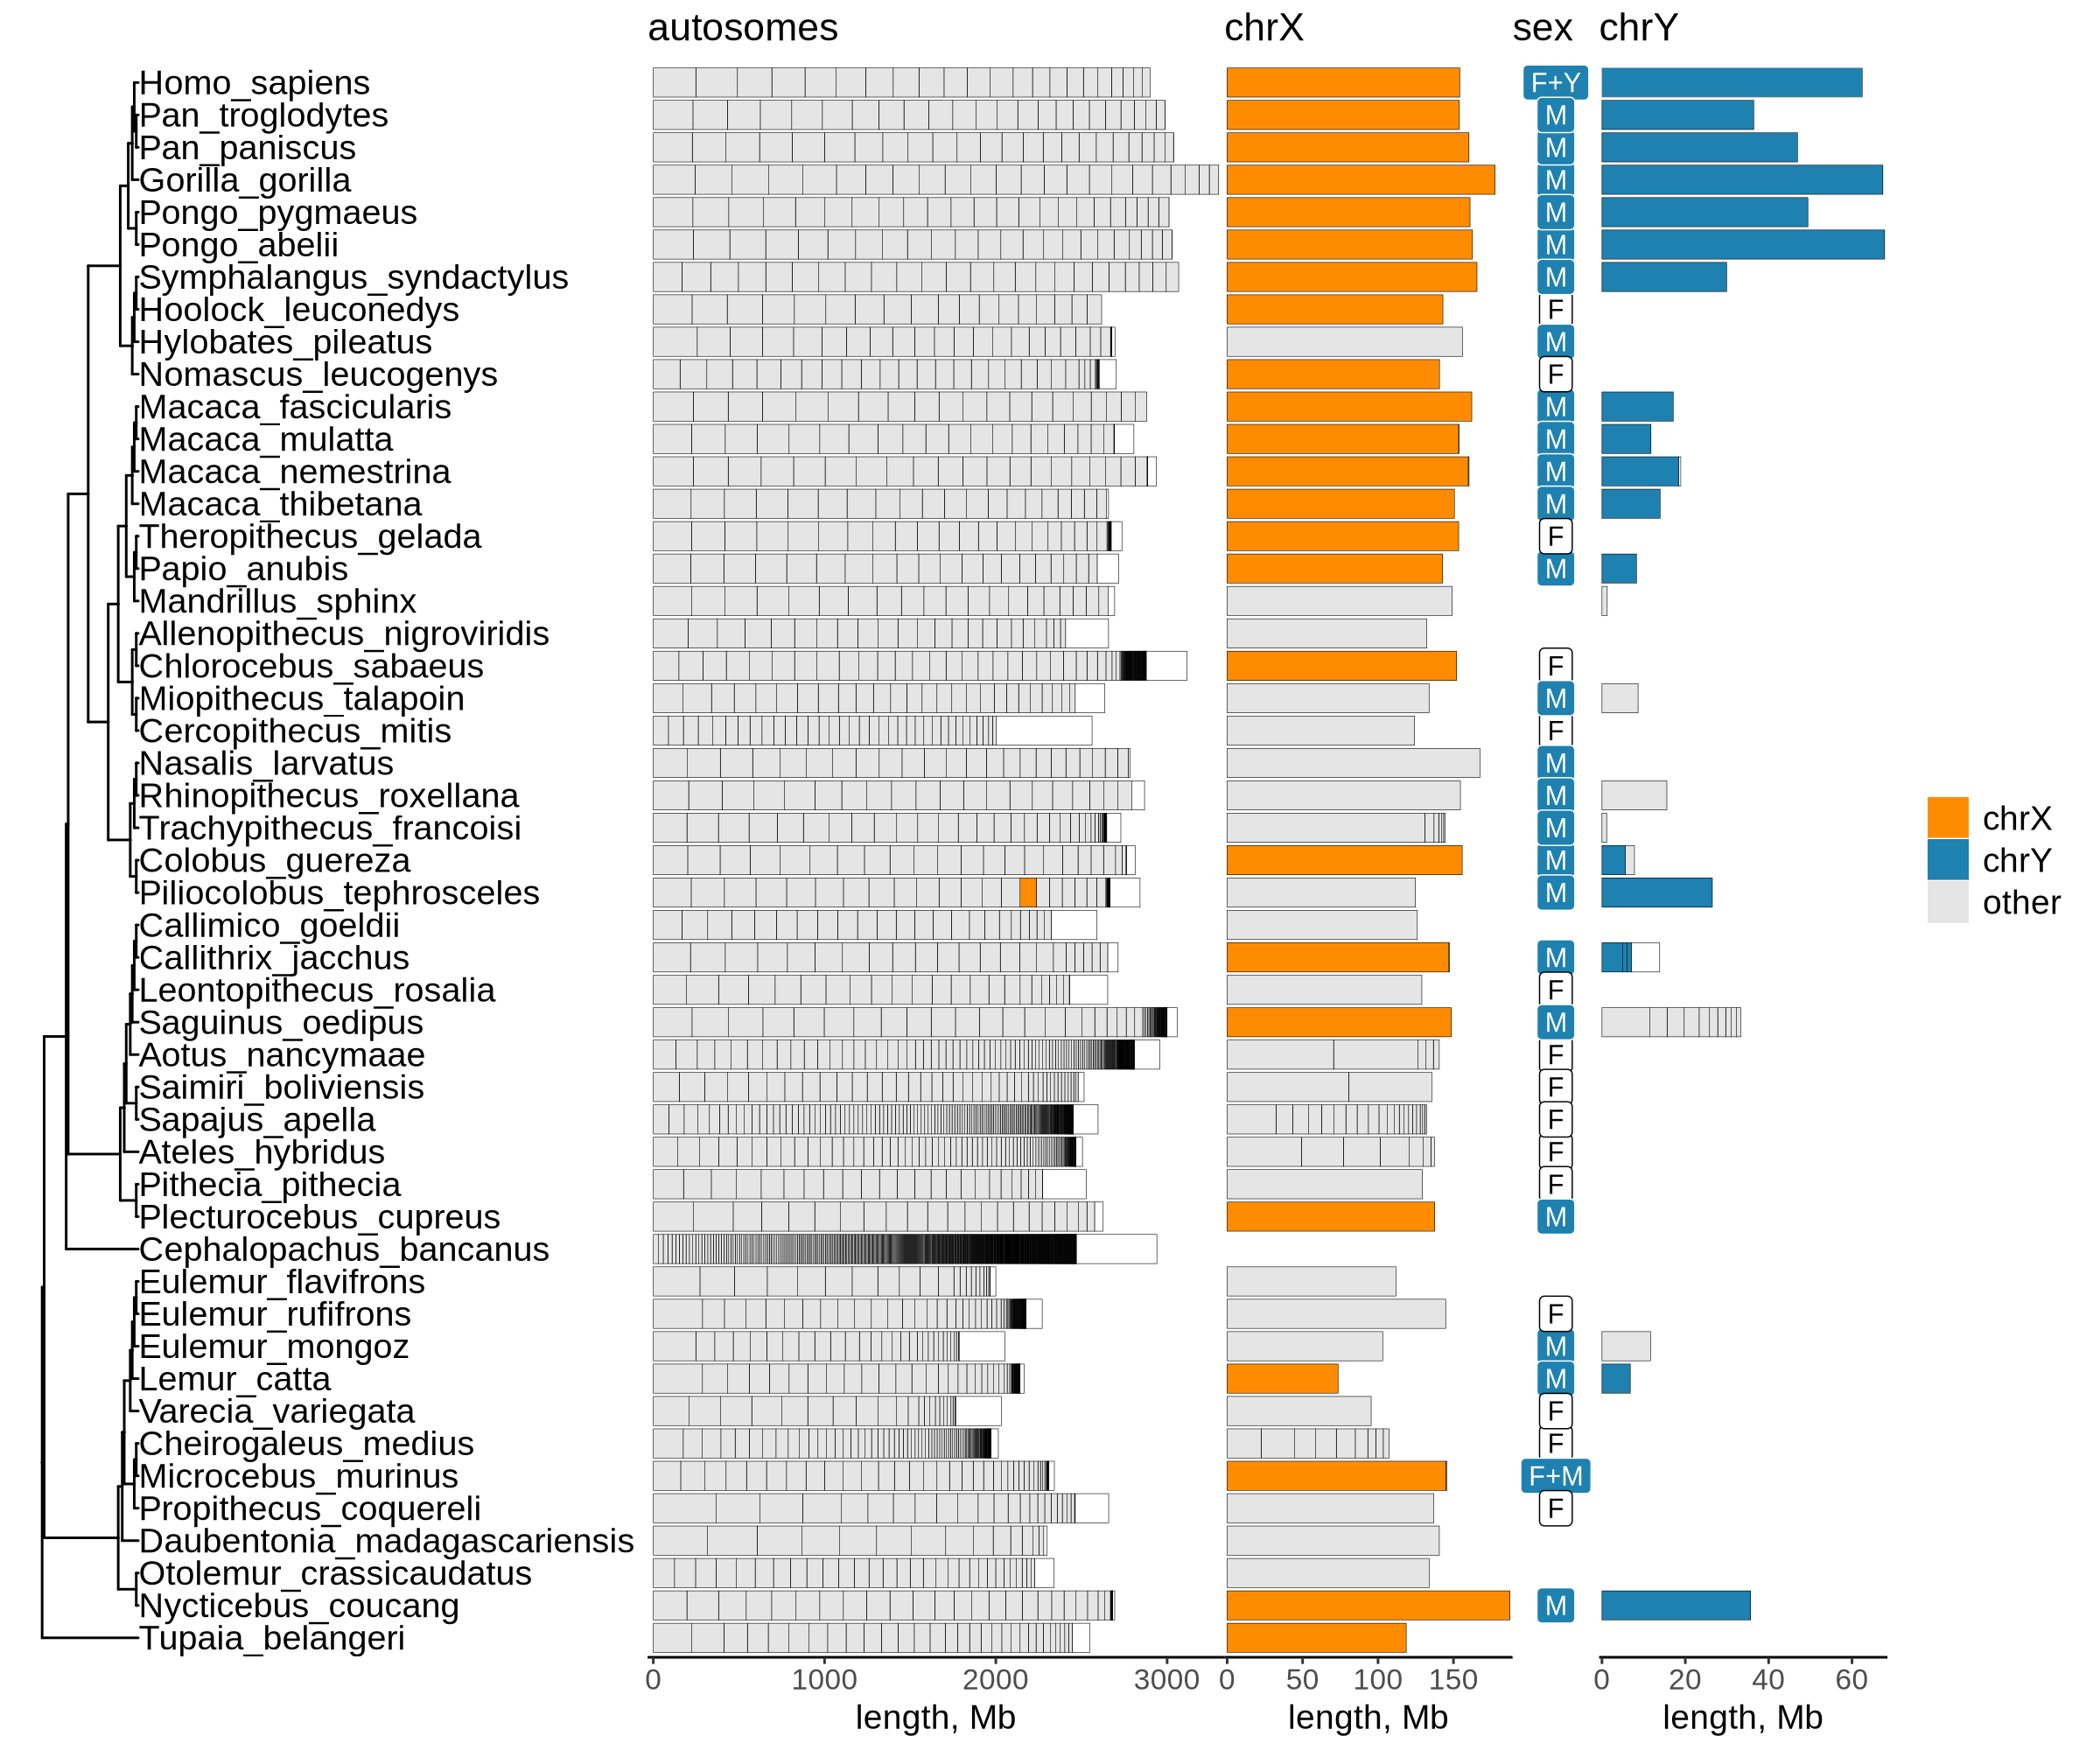

In [81]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)

figure

In [ ]:
pdf('FigureS3.pdf', 
    width = 12, 
    height = 11)
figure
dev.off()